In [18]:
import os

import numpy as np
import scanpy as sc

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS/'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS.preprocess import get_tf_activity, tf_to_adata
from scLEMBAS import io

In [5]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
seed = 888

In [7]:
rpe1 = sc.read_h5ad(os.path.join(data_path, 'raw', 'rpe1_normalized_singlecell_01.h5ad'))
rpe1_scperturb = sc.read_h5ad(os.path.join(data_path, 'raw', 'scperturb_ReplogleWeissman2022_rpe1.h5ad'))

Some basic QC:

In [ ]:
# # this doesn't filter anything out -- good sign, indicates already QC'd
# sc.pp.filter_cells(rpe1, min_genes=100)
# sc.pp.filter_genes(rpe1, min_cells=100)

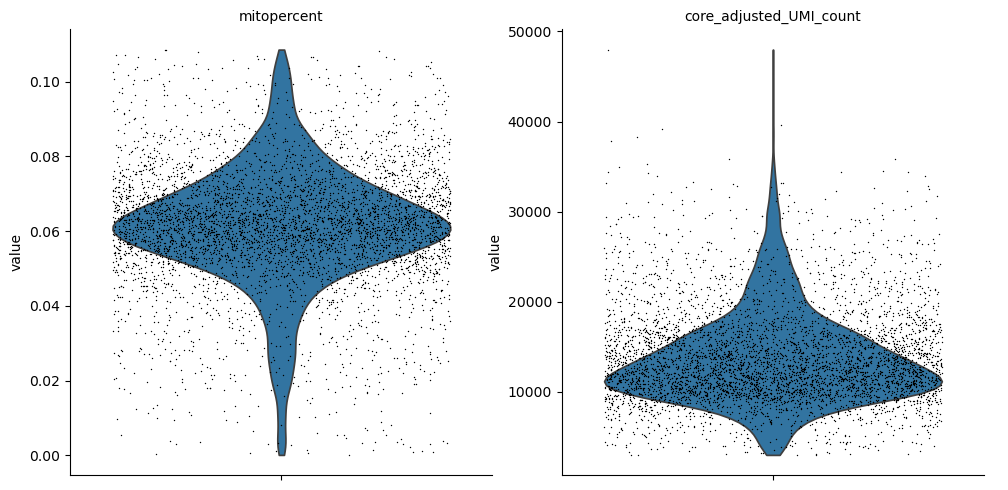

In [22]:
np.random.seed(seed)
subset = np.random.choice(rpe1.obs_names, int(5e3), replace = False)
sc.pl.violin(
    rpe1[test, :],
    ["mitopercent", "core_adjusted_UMI_count"],
    jitter=0.4,
    multi_panel=True,
)

# filters out 771 out of 247914 cells
rpe1 = rpe1[rpe1.obs["core_adjusted_UMI_count"] < int(35e3), :]

Use scPerturb data to map the ENSG to the gene names:

In [56]:
if rpe1_scperturb.var.ensembl_id.nunique() != rpe1_scperturb.var.shape[0]:
    raise ValueError('There is a not a 1-to-1 mapping of gene name to ensembl ID')
if sorted(rpe1_scperturb.var.ensembl_id) != sorted(rpe1.var_names):
    raise ValueError('There is not a 1-to-1 correspondence between the original data and scPerturb')
    
gene_map = dict(zip(rpe1_scperturb.var.ensembl_id, rpe1_scperturb.var.index))
rpe1.var_names = rpe1.var_names.map(gene_map)
del rpe1_scperturb

Exclude perturbations with fewer than 20 cells:

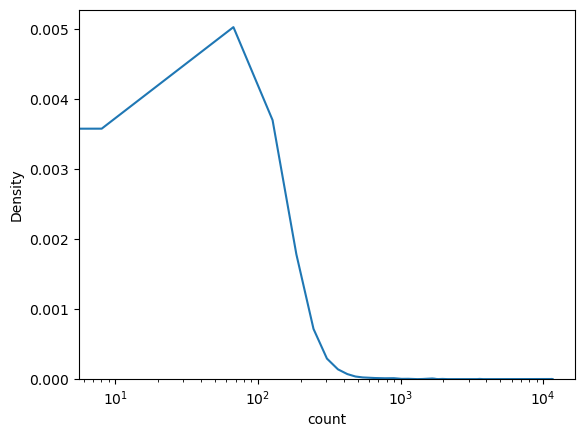

In [74]:
fig, ax = plt.subplots()
sns.kdeplot(rpe1.obs.gene.value_counts(), ax = ax)
ax.set_xscale('log')

In [82]:
thresh = 50
n_perturbations = rpe1.obs.gene.nunique()
retain = rpe1.obs.gene.value_counts()[rpe1.obs.gene.value_counts() >= thresh].index.tolist()
rpe1 = rpe1[rpe1.obs.gene.isin(retain),:]
print('Filtering for perturbations present in atleast {} single-cells decreases the no. of perturbations from {} to {}'.format(thresh, n_perturbations, rpe1.obs.gene.nunique()))


Filtering for perturbations present in atleast 50 single-cells decreases the no. of perturbations from 2394 to 1607
